In [1]:
import duckdb
import os

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
import seaborn as sns

In [5]:
from sklearn.decomposition import PCA

In [6]:
import matplotlib.pyplot as plt

In [109]:
from sklearn.metrics import silhouette_score

In [7]:
con = duckdb.connect(database = ':memory:')

In [45]:
medicare2023_MedicareTotalPymtByState_df_copy2 = con.execute("""SELECT
    HCPCS_Cd,
    Rndrng_Prvdr_State_Abrvtn,
    SUM(Avg_Mdcr_Pymt_Amt*Tot_Srvcs) as total_mdcr_spending,
    sum(Tot_Srvcs) as total_services
FROM 'medicare_2023.parquet'
WHERE Avg_Mdcr_Pymt_Amt IS NOT NULL
AND Tot_Srvcs IS NOT NULL
GROUP BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn
ORDER BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn;""").df()

In [46]:
medicare2023_MedicareTotalPymtByState_df_copy2

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,total_mdcr_spending,total_services
0,0001A,CA,2113.600000,53.0
1,0001A,FL,883.470000,21.0
2,0001A,IL,1077.250000,25.0
3,0001A,MA,1173.380000,26.0
4,0001A,MS,1496.000000,40.0
...,...,...,...,...
128643,V2785,UT,191680.410001,56.0
128644,V2785,VA,876717.610000,236.0
128645,V2785,VT,56792.960000,16.0
128646,V2785,WA,827263.669996,235.0


In [83]:
#2023 version: for each provider, we are computing the weighted average estimated medicare dollars contributed for the service they provided(Avg_Mdcr_Pymt_Amt*Tot_Srvcs), then summing across all providers

medicare2023_MedicareWghtdAvgPymtByState_df = con.execute("""SELECT HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn, sum(Avg_Mdcr_Pymt_Amt*Tot_Srvcs) / sum(Tot_Srvcs) as est_wght_avg_Mdcr_paid, sum(Tot_Srvcs) as total_services FROM 'medicare_2023.parquet' WHERE Avg_Mdcr_Pymt_Amt IS NOT NULL AND Tot_Srvcs IS NOT NULL GROUP BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn ORDER BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn;""" ).df()

In [84]:
#2023: total estimated medicare spending per service per state
#this estimates the total amount of money that medicare covered for each service by state
medicare2023_MedicareWghtdAvgPymtByState_df

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
0,0001A,CA,39.879245,53.0
1,0001A,FL,42.070000,21.0
2,0001A,IL,43.090000,25.0
3,0001A,MA,45.130000,26.0
4,0001A,MS,37.400000,40.0
...,...,...,...,...
128643,V2785,UT,3422.864464,56.0
128644,V2785,VA,3714.905127,236.0
128645,V2785,VT,3549.560000,16.0
128646,V2785,WA,3520.270936,235.0


In [85]:
medicare2023_MedicareWghtdAvgPymtByState_df.dropna()
medicare2023_MedicareWghtdAvgPymtByState_df

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
0,0001A,CA,39.879245,53.0
1,0001A,FL,42.070000,21.0
2,0001A,IL,43.090000,25.0
3,0001A,MA,45.130000,26.0
4,0001A,MS,37.400000,40.0
...,...,...,...,...
128643,V2785,UT,3422.864464,56.0
128644,V2785,VA,3714.905127,236.0
128645,V2785,VT,3549.560000,16.0
128646,V2785,WA,3520.270936,235.0


In [86]:
#grabbing the top 50 services for 2023

top50_services2023 = medicare2023_MedicareWghtdAvgPymtByState_df['HCPCS_Cd'].value_counts().nlargest(50).index
top50_services2023

Index(['99223', '99232', '00731', '99213', '99283', '99214', '97112', '97140',
       '99204', '99233', '99291', '99222', '99215', '99285', '00811', '99212',
       '99203', '70450', '71046', 'G0008', '92014', '72125', '74176', '92250',
       '74177', '00812', '99284', '73502', '73030', '71250', 'G0439', '97530',
       '97110', '00142', '71045', '93970', '96372', '76775', '97161', '71260',
       '72100', '76705', '92134', '66984', '93880', '73630', '93010', '36620',
       '92083', '72170'],
      dtype='object', name='HCPCS_Cd')

In [87]:
#the dataframe below shows the top 50 services (the services that were provided most) in 2023

top50Services_2023df = medicare2023_MedicareWghtdAvgPymtByState_df[medicare2023_MedicareWghtdAvgPymtByState_df['HCPCS_Cd'].isin(top50_services2023)]
top50Services_2023df

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
257,00142,AE,93.762558,129.0
258,00142,AK,110.721937,3129.0
259,00142,AL,53.032879,30497.0
260,00142,AP,93.495074,136.0
261,00142,AR,82.261099,18456.0
...,...,...,...,...
117239,G0439,WI,119.666352,179628.0
117240,G0439,WV,116.709788,44745.0
117241,G0439,WY,121.637937,18687.0
117242,G0439,XX,126.945975,323.0


**Linear Regression Implementation with Top 50 Services**

In [88]:
#Preparation for Linear Regression
#dummy encoding HCPCS_cd and Rndrng_Prvdr_State_Abrvtn categorical variables
encoded_dfTop50Service2023 = pd.get_dummies(top50Services_2023df, columns=['HCPCS_Cd','Rndrng_Prvdr_State_Abrvtn'], drop_first = True, dtype=int)

encoded_dfTop50Service2023

,est_wght_avg_Mdcr_paid,total_services,HCPCS_Cd_00731,HCPCS_Cd_00811,HCPCS_Cd_00812,HCPCS_Cd_36620,HCPCS_Cd_66984,HCPCS_Cd_70450,HCPCS_Cd_71045,HCPCS_Cd_71046,...,Rndrng_Prvdr_State_Abrvtn_UT,Rndrng_Prvdr_State_Abrvtn_VA,Rndrng_Prvdr_State_Abrvtn_VI,Rndrng_Prvdr_State_Abrvtn_VT,Rndrng_Prvdr_State_Abrvtn_WA,Rndrng_Prvdr_State_Abrvtn_WI,Rndrng_Prvdr_State_Abrvtn_WV,Rndrng_Prvdr_State_Abrvtn_WY,Rndrng_Prvdr_State_Abrvtn_XX,Rndrng_Prvdr_State_Abrvtn_ZZ
257,93.762558,129.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
258,110.721937,3129.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
259,53.032879,30497.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
260,93.495074,136.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
261,82.261099,18456.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117239,119.666352,179628.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
117240,116.709788,44745.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
117241,121.637937,18687.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
117242,126.945975,323.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [89]:
# Model 1: predictors are total_services, HCPCS_cd (medical service code), and Rndrng_Prvdr_State_Abrvtn (state)
# Define features (X) and target (y), INCLUDES state
Model1X_top50Service2023 = encoded_dfTop50Service2023.drop('est_wght_avg_Mdcr_paid', axis=1)
y_top50Service2023 = encoded_dfTop50Service2023['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model1 = LinearRegression()
model1.fit(Model1X_top50Service2023,y_top50Service2023)

LinearRegression()

In [90]:
#Model 1: R Squared total_services, HCPCS_cd (medical service code), and Rndrng_Prvdr_State_Abrvtn (state)
r_squared_top50Services2023Model1 = model1.score(Model1X_top50Service2023,y_top50Service2023)
r_squared_top50Services2023Model1

0.7996618727449887

In [91]:
# Model 2: predictors are HCPCS_cd (medical service code), and Rndrng_Prvdr_State_Abrvtn (state)
# Define features (X) and target (y), INCLUDES state
Model2X_top50Service2023 = encoded_dfTop50Service2023.drop(['est_wght_avg_Mdcr_paid','total_services'], axis=1)
y_top50Service2023 = encoded_dfTop50Service2023['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model2 = LinearRegression()
model2.fit(Model2X_top50Service2023,y_top50Service2023)

LinearRegression()

In [92]:
#Model 2: R Squared HCPCS_cd (medical service code), and Rndrng_Prvdr_State_Abrvtn (state)
r_squared_top50Services2023Model2 = model2.score(Model2X_top50Service2023,y_top50Service2023)
r_squared_top50Services2023Model2

0.7992811604401269

In [93]:
# Model 3: predictors are HCPCS_cd (medical service code)
# Define features (X) and target (y), INCLUDES state
Model3X_top50Service2023 = encoded_dfTop50Service2023.drop(columns=[
        col for col in encoded_dfTop50Service2023.columns
        if col.startswith('Rndrng_Prvdr_State_Abrvtn_')
    ] + ['est_wght_avg_Mdcr_paid','total_services'], axis=1)
y_top50Service2023 = encoded_dfTop50Service2023['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model3 = LinearRegression()
model3.fit(Model3X_top50Service2023,y_top50Service2023)

LinearRegression()

In [94]:
#Model 3: R Squared HCPCS_cd (medical service code)
r_squared_top50Services2023Model3 = model3.score(Model3X_top50Service2023,y_top50Service2023)
r_squared_top50Services2023Model3

0.786011098853045

**2023 K Means Cluster Implementation**

In [159]:
df_service_2023 =(
    top50Services_2023df.groupby('HCPCS_Cd', as_index=False)[['est_wght_avg_Mdcr_paid']].mean()
)

df_service_2023

,HCPCS_Cd,est_wght_avg_Mdcr_paid
0,00142,81.815653
1,00731,86.064038
2,00811,83.738290
3,00812,86.503662
4,36620,34.625693
5,66984,371.033500
6,70450,30.753969
7,71045,6.807066
8,71046,11.437032
9,71250,47.487928


In [160]:
X = df_service_2023[['est_wght_avg_Mdcr_paid']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.33409639],
       [ 0.40678202],
       [ 0.3669908 ],
       [ 0.41430354],
       [-0.47327681],
       [ 5.2823255 ],
       [-0.53951813],
       [-0.94922579],
       [-0.87001167],
       [-0.25321678],
       [-0.26710192],
       [-0.79159118],
       [-0.45624432],
       [-0.90720547],
       [-0.8064134 ],
       [-0.75969037],
       [-0.78434141],
       [ 0.1040055 ],
       [ 0.30927736],
       [-0.61996753],
       [-0.57250106],
       [ 0.28849938],
       [-0.36186696],
       [-0.58458504],
       [-0.64614317],
       [-0.96144728],
       [ 0.29956901],
       [ 0.02355097],
       [-0.89712605],
       [-0.76001162],
       [-0.69920621],
       [-0.79302836],
       [ 0.17942166],
       [-0.64420878],
       [ 0.11494223],
       [ 0.76914552],
       [-0.46175704],
       [-0.11053994],
       [ 0.28616109],
       [ 0.88773023],
       [ 0.60971572],
       [ 1.18713435],
       [-0.02773567],
       [ 0.51269423],
       [-0.20100136],
       [ 0

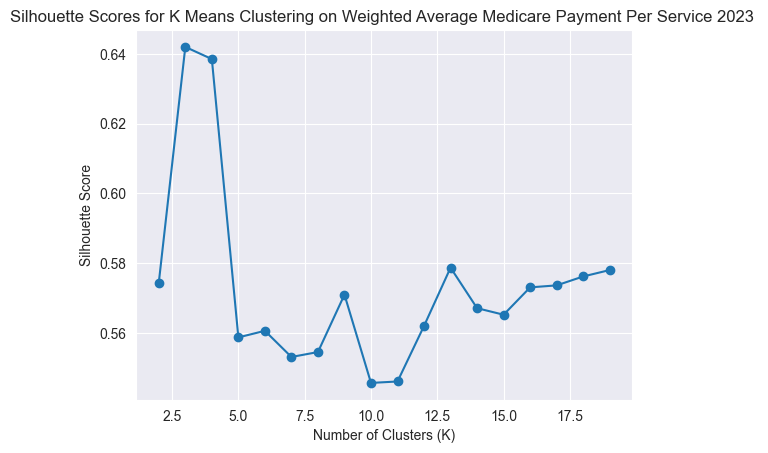

In [161]:
#calculating silhouette score to find optimal k for which n_clusters = k
scores = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2, 20), scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title("Silhouette Scores for K Means Clustering on Weighted Average Medicare Payment Per Service 2023 ")
plt.show()

In [145]:
scores = {}

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
kMaxSilScore = max(scores, key=scores.get)
print("kMaxSilScore is " + str(kMaxSilScore))

kMaxSilScore is 3


In [146]:
kmeans = KMeans(n_clusters=kMaxSilScore, random_state=42, n_init=10)
df_service_2023['cluster'] = kmeans.fit_predict(X_scaled)
df_service_2023

,HCPCS_Cd,est_wght_avg_Mdcr_paid,cluster
0,00142,81.815653,0
1,00731,86.064038,0
2,00811,83.738290,0
3,00812,86.503662,0
4,36620,34.625693,1
5,66984,371.033500,2
6,70450,30.753969,1
7,71045,6.807066,1
8,71046,11.437032,1
9,71250,47.487928,1


In [147]:
df_long = pd.melt(df_service_2023, id_vars=['HCPCS_Cd', 'cluster'],
                  var_name='est_wght_avg_Mdcr_paid', value_name='mean_value')

df_long

,HCPCS_Cd,cluster,est_wght_avg_Mdcr_paid,mean_value
0,00142,0,est_wght_avg_Mdcr_paid,81.815653
1,00731,0,est_wght_avg_Mdcr_paid,86.064038
2,00811,0,est_wght_avg_Mdcr_paid,83.738290
3,00812,0,est_wght_avg_Mdcr_paid,86.503662
4,36620,1,est_wght_avg_Mdcr_paid,34.625693
5,66984,2,est_wght_avg_Mdcr_paid,371.033500
6,70450,1,est_wght_avg_Mdcr_paid,30.753969
7,71045,1,est_wght_avg_Mdcr_paid,6.807066
8,71046,1,est_wght_avg_Mdcr_paid,11.437032
9,71250,1,est_wght_avg_Mdcr_paid,47.487928


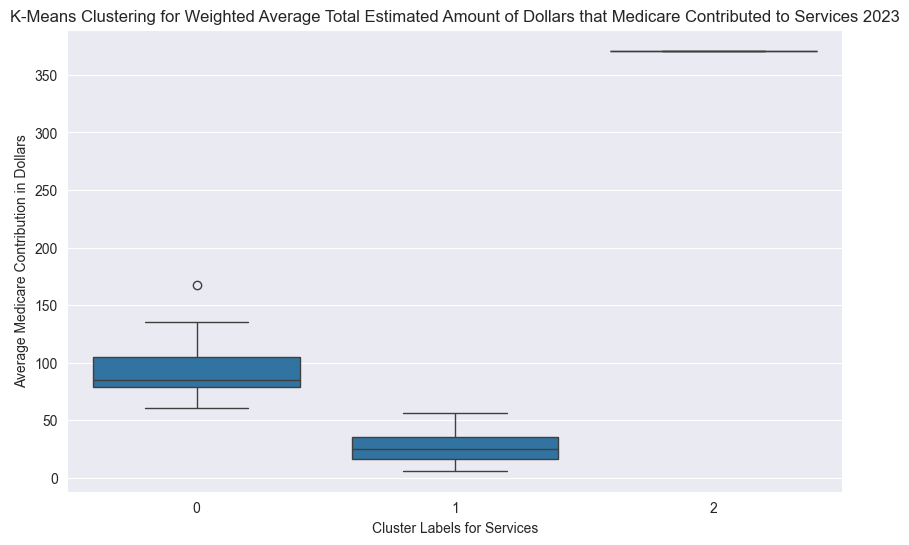

In [149]:
#here is the box plot for k means clustering on average amount of money in dollars that medicare contributed to services, grouped on services variable
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='mean_value', data=df_long)
plt.title('K-Means Clustering for Weighted Average Total Estimated Amount of Dollars that Medicare Contributed to Services 2023')
plt.ylabel('Average Medicare Contribution in Dollars')
plt.xlabel('Cluster Labels for Services')
plt.show()

**2022 Linear Regression Implementation**

In [95]:
#2022 version: for each provider, we are computing the weighted average estimated medicare dollars contributed for the service they provided (Avg_Mdcr_Pymt_Amt*Tot_Srvcs), then summing across all providers

medicare2022_MedicareWghtdAvgPymtByState_df = con.execute("""SELECT HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn, sum(Avg_Mdcr_Pymt_Amt*Tot_Srvcs) / sum(Tot_Srvcs) as est_wght_avg_Mdcr_paid, sum(Tot_Srvcs) as total_services FROM 'medicare_2022.parquet' WHERE Avg_Mdcr_Pymt_Amt IS NOT NULL AND Tot_Srvcs IS NOT NULL GROUP BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn ORDER BY HCPCS_Cd, Rndrng_Prvdr_State_Abrvtn;""" ).df()

In [96]:
#2022: total estimated medicare spending per service per state

medicare2022_MedicareWghtdAvgPymtByState_df

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
0,0001A,AL,36.507436,117.0
1,0001A,AR,35.365161,527.0
2,0001A,AZ,37.496435,115.0
3,0001A,CA,42.940095,8876.0
4,0001A,CO,39.040539,964.0
...,...,...,...,...
130045,V2785,TX,3353.804960,629.0
130046,V2785,UT,3000.033438,32.0
130047,V2785,VA,3369.470526,190.0
130048,V2785,WA,3486.419819,166.0


In [97]:
medicare2022_MedicareWghtdAvgPymtByState_df.dropna()

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
0,0001A,AL,36.507436,117.0
1,0001A,AR,35.365161,527.0
2,0001A,AZ,37.496435,115.0
3,0001A,CA,42.940095,8876.0
4,0001A,CO,39.040539,964.0
...,...,...,...,...
130045,V2785,TX,3353.804960,629.0
130046,V2785,UT,3000.033438,32.0
130047,V2785,VA,3369.470526,190.0
130048,V2785,WA,3486.419819,166.0


In [98]:
#grabbing the top 50 services : seeing which HCPCS_Cd code appear most frequently in dataset, choosing top 50

top50_services = medicare2022_MedicareWghtdAvgPymtByState_df['HCPCS_Cd'].value_counts().nlargest(50).index
top50_services

Index(['99232', '99223', 'G0439', '00731', '00811', '99239', '97140', '99214',
       '99283', '99213', 'G0008', '71046', '99222', '99204', '99212', '99285',
       '99284', '92134', '92250', '76770', '99291', '99215', '99233', '36415',
       '00812', '74176', '74177', '00142', '97530', '76705', '97162', '97112',
       '97110', '96372', '72125', '70450', '99203', '73562', '74018', '76536',
       '99205', '81003', '83036', 'J1100', '93970', '73030', '76700', '92004',
       '99282', '93010'],
      dtype='object', name='HCPCS_Cd')

In [99]:
#the dataframe below shows the top 100 services (the services that were provided most) in 2022

top50Services_2022df = medicare2022_MedicareWghtdAvgPymtByState_df[medicare2022_MedicareWghtdAvgPymtByState_df['HCPCS_Cd'].isin(top50_services)]
top50Services_2022df

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
562,00142,AE,130.473800,50.0
563,00142,AK,110.532105,3473.0
564,00142,AL,58.007722,33547.0
565,00142,AP,65.431960,597.0
566,00142,AR,84.253935,21174.0
...,...,...,...,...
121995,J1100,WA,0.093754,201094.6
121996,J1100,WI,0.092725,67714.0
121997,J1100,WV,0.086160,42150.5
121998,J1100,WY,0.093205,19698.0


In [100]:
encoded_dfTop50Service2022 = pd.get_dummies(top50Services_2022df, columns=['HCPCS_Cd','Rndrng_Prvdr_State_Abrvtn'], drop_first = True, dtype=int)

encoded_dfTop50Service2022

,est_wght_avg_Mdcr_paid,total_services,HCPCS_Cd_00731,HCPCS_Cd_00811,HCPCS_Cd_00812,HCPCS_Cd_36415,HCPCS_Cd_70450,HCPCS_Cd_71046,HCPCS_Cd_72125,HCPCS_Cd_73030,...,Rndrng_Prvdr_State_Abrvtn_UT,Rndrng_Prvdr_State_Abrvtn_VA,Rndrng_Prvdr_State_Abrvtn_VI,Rndrng_Prvdr_State_Abrvtn_VT,Rndrng_Prvdr_State_Abrvtn_WA,Rndrng_Prvdr_State_Abrvtn_WI,Rndrng_Prvdr_State_Abrvtn_WV,Rndrng_Prvdr_State_Abrvtn_WY,Rndrng_Prvdr_State_Abrvtn_XX,Rndrng_Prvdr_State_Abrvtn_ZZ
562,130.473800,50.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
563,110.532105,3473.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
564,58.007722,33547.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
565,65.431960,597.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
566,84.253935,21174.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121995,0.093754,201094.6,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
121996,0.092725,67714.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
121997,0.086160,42150.5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
121998,0.093205,19698.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [101]:
# Define features (X) and target (y), INCLUDES HCPCS Code + State + Total Services as predictors
Model1X_top50Service2022 = encoded_dfTop50Service2022.drop('est_wght_avg_Mdcr_paid', axis=1)
y_top50Service2022 = encoded_dfTop50Service2022['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model12022 = LinearRegression()
model12022.fit(Model1X_top50Service2022,y_top50Service2022)

LinearRegression()

In [102]:
r_squared_top50Services2022Model1 = model12022.score(Model1X_top50Service2022,y_top50Service2022)

In [103]:
r_squared_top50Services2022Model1

0.9719176759288294

In [104]:
# Define features (X) and target (y), INCLUDES HCPCS Code + State as predictors
Model2X_top50Service2022 = encoded_dfTop50Service2022.drop(['est_wght_avg_Mdcr_paid','total_services'], axis=1)
y_top50Service2022 = encoded_dfTop50Service2022['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model2_2022 = LinearRegression()
model2_2022.fit(Model2X_top50Service2022,y_top50Service2022)

LinearRegression()

In [105]:
r_squared_top50Services2022Model2 = model2_2022.score(Model2X_top50Service2022,y_top50Service2022)
r_squared_top50Services2022Model2

0.9719025658290683

In [106]:
# Define features (X) and target (y), INCLUDES Just HCPCS Code
Model3X_top50Service2022 = encoded_dfTop50Service2022.drop(columns=[
        col for col in encoded_dfTop50Service2022.columns
        if col.startswith('Rndrng_Prvdr_State_Abrvtn_')
    ] + ['est_wght_avg_Mdcr_paid','total_services'], axis=1)
y_top50Service2022 = encoded_dfTop50Service2022['est_wght_avg_Mdcr_paid']

#Fit the Linear Regression Model:
model3_2022 = LinearRegression()
model3_2022.fit(Model3X_top50Service2022,y_top50Service2022)

LinearRegression()

In [107]:
r_squared_top50Services2022Model3 = model3_2022.score(Model3X_top50Service2022,y_top50Service2022)
r_squared_top50Services2022Model3

0.9604872936849375

**K Means Cluster 2022: Applying K Means Cluster on est_wght_avg_Mdcr_paid variable to visually show that there is variation in payment per service but not variation in payment per state**

In [162]:
#making a copy of the dataframe for k means cluster: clustering solely based off of payment
top50Services_2022df_COPY = top50Services_2022df.copy()
totalMedicarePaymentFeature = top50Services_2022df_COPY[['est_wght_avg_Mdcr_paid']]

In [163]:
top50Services_2022df_COPY

,HCPCS_Cd,Rndrng_Prvdr_State_Abrvtn,est_wght_avg_Mdcr_paid,total_services
562,00142,AE,130.473800,50.0
563,00142,AK,110.532105,3473.0
564,00142,AL,58.007722,33547.0
565,00142,AP,65.431960,597.0
566,00142,AR,84.253935,21174.0
...,...,...,...,...
121995,J1100,WA,0.093754,201094.6
121996,J1100,WI,0.092725,67714.0
121997,J1100,WV,0.086160,42150.5
121998,J1100,WY,0.093205,19698.0


In [164]:
# for every medical service (HCPCS Code), calculated the average weighted average medicare payment mean
df_service_2022 =(
    top50Services_2022df.groupby('HCPCS_Cd', as_index=False)[['est_wght_avg_Mdcr_paid']].mean()
)

df_service_2022

,HCPCS_Cd,est_wght_avg_Mdcr_paid
0,00142,84.953272
1,00731,88.437267
2,00811,86.665998
3,00812,88.419364
4,36415,2.953169
5,70450,31.015740
6,71046,11.488981
7,72125,36.366155
8,73030,15.110866
9,73562,18.684811


In [165]:
X = df_service_2022[['est_wght_avg_Mdcr_paid']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.61220661],
       [ 0.69121488],
       [ 0.65104693],
       [ 0.69080888],
       [-1.24734993],
       [-0.61096124],
       [-1.05377913],
       [-0.48962726],
       [-0.97164387],
       [-0.89059576],
       [-1.12641017],
       [ 0.24889285],
       [ 0.55232192],
       [-0.32942179],
       [-0.24061827],
       [-0.72739821],
       [-0.42580578],
       [-1.26423329],
       [-1.09784766],
       [ 0.71031947],
       [-0.6762747 ],
       [-0.75728907],
       [-1.17297649],
       [ 0.03044327],
       [-1.08623204],
       [-0.89570285],
       [-0.81036978],
       [-0.94190846],
       [ 0.34983103],
       [-0.74066705],
       [ 0.29436242],
       [ 1.19606963],
       [ 2.1472712 ],
       [-0.51373419],
       [-0.03225957],
       [ 0.5017507 ],
       [ 1.33851944],
       [ 1.01688028],
       [ 2.12465479],
       [-0.06354387],
       [ 0.49293922],
       [ 0.5330944 ],
       [-0.64354184],
       [-0.12803423],
       [ 0.77436631],
       [ 1

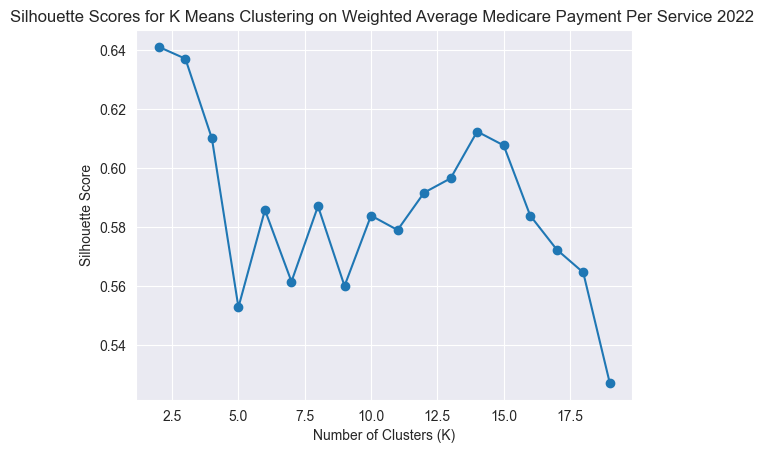

In [166]:
#using silhouette score to find optimal k = n_clusters

scores = []

for k in range(2,20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    scores.append(score)
plt.plot(range(2,20),scores,marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title("Silhouette Scores for K Means Clustering on Weighted Average Medicare Payment Per Service 2022 ")
plt.show()

In [167]:
#using silhouette score to find optimal k = n_clusters
scoresDict = {}

for k in range(2,20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    scoresDict[k] = score
kWithMaxSilScore = max(scoresDict, key=scoresDict.get)
print("optimal amount of clusters with highest silhouette score is k = ", kWithMaxSilScore)

optimal amount of clusters with highest silhouette score is k =  2


In [168]:
kmeans = KMeans(n_clusters=kWithMaxSilScore, random_state=42, n_init=10)
df_service_2022['cluster'] = kmeans.fit_predict(X_scaled)
df_service_2022

,HCPCS_Cd,est_wght_avg_Mdcr_paid,cluster
0,00142,84.953272,1
1,00731,88.437267,1
2,00811,86.665998,1
3,00812,88.419364,1
4,36415,2.953169,0
5,70450,31.015740,0
6,71046,11.488981,0
7,72125,36.366155,0
8,73030,15.110866,0
9,73562,18.684811,0


In [174]:
#medical services HCPCS in cluster 1 with the HIGHEST estimated weighted average medicare coverage per service
top5HCPCS_Cluster1_2022 = df_service_2022[df_service_2022['cluster'] == 1].sort_values(by='est_wght_avg_Mdcr_paid', ascending=False).head(5)

In [175]:
top5HCPCS_Cluster1_2022

,HCPCS_Cd,est_wght_avg_Mdcr_paid,cluster
46,99291,176.721276,1
32,99205,152.644387,1
38,99223,151.647080,1
45,99285,144.132064,1
48,G0439,119.022775,1


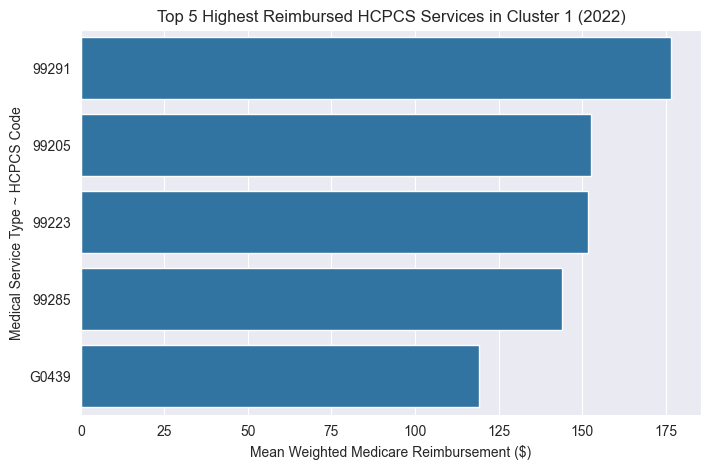

In [186]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top5HCPCS_Cluster1_2022,
    x='est_wght_avg_Mdcr_paid',
    y='HCPCS_Cd'
)

plt.title('Top 5 Highest Reimbursed HCPCS Services in Cluster 1 (2022)')
plt.xlabel('Mean Weighted Medicare Reimbursement ($)')
plt.ylabel('Medical Service Type ~ HCPCS Code')

plt.show()

In [176]:
#medical services HCPCS in cluster 0 with the HIGHEST estimated weighted average medicare coverage per service
top5HCPCS_Cluster0_2022 = df_service_2022[df_service_2022['cluster'] == 0].sort_values(by='est_wght_avg_Mdcr_paid', ascending=False).head(5)

In [177]:
top5HCPCS_Cluster0_2022

,HCPCS_Cd,est_wght_avg_Mdcr_paid,cluster
23,93970,59.299492,0
34,99213,56.534511,0
39,99232,55.154980,0
43,99283,52.311175,0
14,76700,47.346603,0


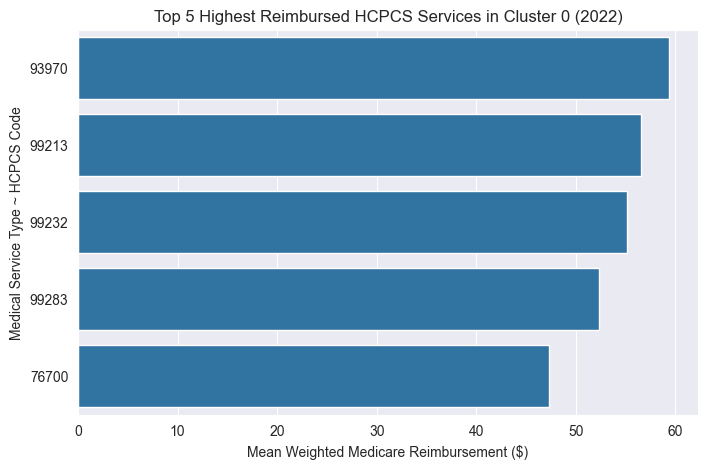

In [185]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top5HCPCS_Cluster0_2022,
    x='est_wght_avg_Mdcr_paid',
    y='HCPCS_Cd'
)

plt.title('Top 5 Highest Reimbursed HCPCS Services in Cluster 0 (2022)')
plt.xlabel('Mean Weighted Medicare Reimbursement ($)')
plt.ylabel('Medical Service Type ~ HCPCS Code')

plt.show()

In [178]:
#medical services HCPCS in cluster 0 with the HIGHEST estimated weighted average medicare coverage per service
bottom5HCPCS_Cluster0_2022 = df_service_2022[df_service_2022['cluster'] == 0].sort_values(by='est_wght_avg_Mdcr_paid', ascending=True).head(5)

In [179]:
bottom5HCPCS_Cluster0_2022

,HCPCS_Cd,est_wght_avg_Mdcr_paid,cluster
49,J1100,0.091256,0
17,81003,2.208670,0
4,36415,2.953169,0
22,93010,6.232784,0
10,74018,8.286200,0


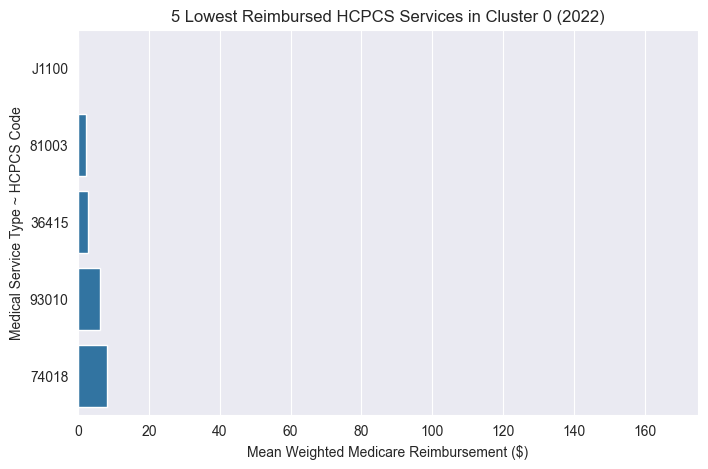

In [188]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=bottom5HCPCS_Cluster0_2022,
    x='est_wght_avg_Mdcr_paid',
    y='HCPCS_Cd'
)

plt.title('5 Lowest Reimbursed HCPCS Services in Cluster 0 (2022)')
plt.xlabel('Mean Weighted Medicare Reimbursement ($)')
plt.ylabel('Medical Service Type ~ HCPCS Code')
plt.xlim(0, 175)
plt.show()

In [169]:
df_long = pd.melt(df_service_2022, id_vars=['HCPCS_Cd', 'cluster'],
                  var_name='est_wght_avg_Mdcr_paid', value_name='mean_value')

df_long

,HCPCS_Cd,cluster,est_wght_avg_Mdcr_paid,mean_value
0,00142,1,est_wght_avg_Mdcr_paid,84.953272
1,00731,1,est_wght_avg_Mdcr_paid,88.437267
2,00811,1,est_wght_avg_Mdcr_paid,86.665998
3,00812,1,est_wght_avg_Mdcr_paid,88.419364
4,36415,0,est_wght_avg_Mdcr_paid,2.953169
5,70450,0,est_wght_avg_Mdcr_paid,31.015740
6,71046,0,est_wght_avg_Mdcr_paid,11.488981
7,72125,0,est_wght_avg_Mdcr_paid,36.366155
8,73030,0,est_wght_avg_Mdcr_paid,15.110866
9,73562,0,est_wght_avg_Mdcr_paid,18.684811


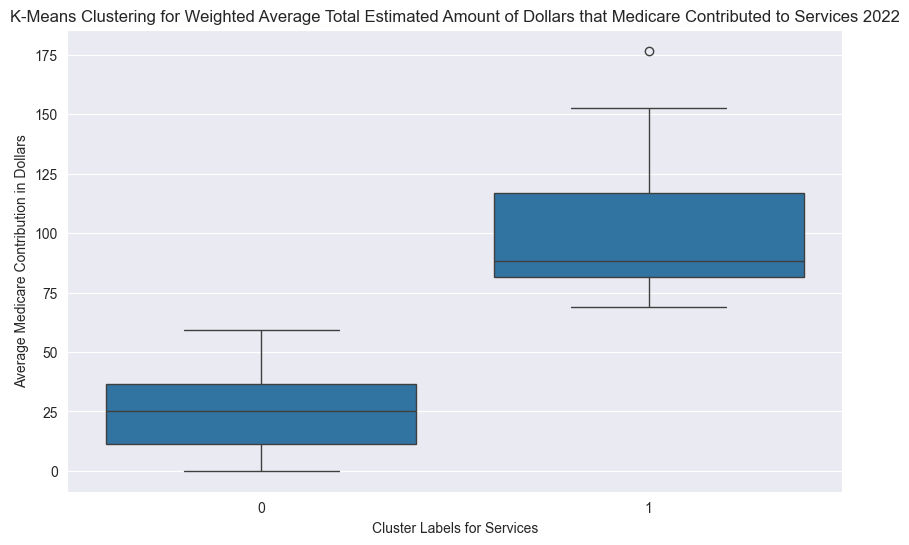

In [171]:
#here is the box plot for k means clustering on average amount of money in dollars that medicare contributed to services, grouped on services variable
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='mean_value', data=df_long)
plt.title('K-Means Clustering for Weighted Average Total Estimated Amount of Dollars that Medicare Contributed to Services 2022')
plt.ylabel('Average Medicare Contribution in Dollars')
plt.xlabel('Cluster Labels for Services')
plt.show()

Working with the Part B and Part D Datasets Now

In [109]:
Medicare_PartD_SpendingByDrug_df = pd.read_excel("Medicare_Part_D_SpendingByDrug.xlsx")
Medicare_PartD_SpendingByDrug_df

,Brnd_Name,Gnrc_Name,Tot_Mftr,Mftr_Name,Tot_Spndng_2019,Tot_Dsg_Unts_2019,Tot_Clms_2019,Tot_Benes_2019,Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,Avg_Spnd_Per_Clm_2019,...,Tot_Spndng_2023,Tot_Dsg_Unts_2023,Tot_Clms_2023,Tot_Benes_2023,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,Avg_Spnd_Per_Clm_2023,Avg_Spnd_Per_Bene_2023,Outlier_Flag_2023,Chg_Avg_Spnd_Per_Dsg_Unt_22_23,CAGR_Avg_Spnd_Per_Dsg_Unt_19_23
0,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Overall,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
1,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Owen Mumford Us,139201.68,642471.0,5392.0,1878.0,0.216788,25.816335,...,44355.04,195672.0,1613,699.0,0.227162,27.498475,63.454993,0.0,0.005702,0.011754
2,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Overall,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
3,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Owen Mumford Us,343031.42,1830596.0,14581.0,5319.0,0.187389,23.525919,...,97951.18,406617.0,3269,1267.0,0.240932,29.963652,77.309534,0.0,0.022165,0.064848
4,Abacavir,Abacavir Sulfate,5,Overall,10110328.45,3316293.0,42629.0,6085.0,3.482725,237.170200,...,5287295.41,1648593.0,19632,2809.0,3.594357,269.320263,1882.269637,0.0,-0.071481,0.007919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14304,Zyvox,Linezolid,1,Overall,652488.55,5419.0,110.0,69.0,213.322618,5931.714091,...,50085.86,670.0,30,26.0,74.755015,1669.528667,1926.379231,1.0,-0.138851,-0.230602
14305,Zyvox,Linezolid,1,Pharmacia-Upjhn,652488.55,5419.0,110.0,69.0,213.322618,5931.714091,...,50085.86,670.0,30,26.0,74.755015,1669.528667,1926.379231,1.0,-0.138851,-0.230602
14306,Zyvox,Linezolid In Dextrose 5%,2,Overall,116364.60,564610.0,202.0,105.0,0.205186,576.062376,...,29011.27,185700.0,85,32.0,0.156035,341.309059,906.602188,0.0,-0.050758,-0.066168
14307,Zyvox,Linezolid In Dextrose 5%,1,Pharmacia-Upjhn,97241.77,454210.0,158.0,88.0,0.214090,615.454241,...,21614.77,137400.0,59,25.0,0.157313,366.352034,864.590800,0.0,-0.029488,-0.074147


In [116]:
Medicare_PartB_SpendingByDrug_df = pd.read_excel("Medicare_Part_B_SpendingByDrug.xlsx")

Medicare_PartB_SpendingByDrug_df

,HCPCS_Cd,HCPCS_Desc,Brnd_Name,Gnrc_Name,Tot_Spndng_2019,Tot_Dsg_Unts_2019,Tot_Clms_2019,Tot_Benes_2019,Avg_Spndng_Per_Dsg_Unt_2019,Avg_Spndng_Per_Clm_2019,...,Tot_Dsg_Unts_2023,Tot_Clms_2023,Tot_Benes_2023,Avg_Spndng_Per_Dsg_Unt_2023,Avg_Spndng_Per_Clm_2023,Avg_Spndng_Per_Bene_2023,Outlier_Flag_2023,Avg_DY23_ASP_Price,Chg_Avg_Spndng_Per_Dsg_Unt_22_23,CAGR_Avg_Spnd_Per_Dsg_Unt_19_23
0,90371,Hepatitis b immune globulin for injection into...,HyperHEP B*,Hepatitis B Immune Globulin*,133840.00,1253.0,312.0,161.0,106.815642,428.974359,...,550.0,142,59.0,129.610418,502.012183,1208.232712,0,133.53350,-0.045204,0.049545
1,90375,Rabies immune globulin for injection,HyperRAB*,Rabies Immune Globulin/PF*,9387991.58,33961.0,3395.0,3366.0,276.434486,2765.240524,...,34896.0,3388,3369.0,289.870575,2985.632698,3002.470638,0,294.21400,0.044689,0.011936
2,90376,Rabies immune globulin for injection beneath t...,Imogam Rabies-HT,Rabies Immune Globulin/PF,1258402.96,4708.0,498.0,491.0,267.290348,2526.913574,...,1791.0,207,207.0,268.687398,2324.730097,2324.730097,0,259.64950,-0.201161,0.001304
3,90377,Rabies immune globulin for injection beneath t...,Kedrab,Rabies Immune Globulin/PF,NaN,NaN,NaN,NaN,NaN,NaN,...,8585.0,864,862.0,235.154436,2336.575035,2341.996323,0,240.97325,0.015076,0.023275
4,90632,Hepatitis a vaccine adult dosage,Havrix*,Hepatitis A Virus Vaccine/PF*,80365.23,1408.0,1408.0,1318.0,57.077578,57.077578,...,91.0,91,89.0,84.566044,84.566044,86.466404,1,70.55075,0.316677,0.103272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,Q9965,"Low osmolar contrast material, 100-199 mg/ml i...",Omnipaque,Iohexol,497015.66,662550.0,34305.0,22637.0,0.750156,14.488141,...,1505272.4,56347,23258.0,1.224842,32.720825,79.272522,0,1.35500,0.618339,0.130400
730,Q9966,"Low osmolar contrast material, 200-299 mg/ml i...",Iodixanol (Q9966)*,Iodixanol*,1773023.78,5722774.8,344855.0,172458.0,0.309819,5.141360,...,4190689.2,262346,144372.0,0.432924,6.915482,12.566488,0,0.43950,0.291761,0.087241
731,Q9967,"Low osmolar contrast material, 300-399 mg/ml i...",Iodixanol (Q9967)*,Iodixanol*,11267562.59,97660255.9,1256162.0,920889.0,0.115375,8.969832,...,96084497.6,1225867,916303.0,0.148452,11.635802,15.566844,0,0.15000,0.258775,0.065046
732,Q9991,"Injection, buprenorphine extended-release (sub...",Sublocade (Q9991),Buprenorphine,294179.57,185.0,185.0,45.0,1590.159838,1590.159838,...,623.0,623,146.0,1661.877785,1661.877785,7091.437397,0,1848.25600,-0.009764,0.011089


In [141]:

#Average Spending Per Dosage Unit Part B

partB_avgspend_perdsg_cols = [
    'Avg_Spndng_Per_Dsg_Unt_2019',
    'Avg_Spndng_Per_Dsg_Unt_2020',
    'Avg_Spndng_Per_Dsg_Unt_2021',
    'Avg_Spndng_Per_Dsg_Unt_2022',
    'Avg_Spndng_Per_Dsg_Unt_2023']


partB_long_avgspend_perdsg = Medicare_PartB_SpendingByDrug_df.melt(
    id_vars=['Gnrc_Name'],
    value_vars=partB_avgspend_perdsg_cols,
    var_name='Year',
    value_name='Avg_Spend_Per_Unit'
)

partB_long_avgspend_perdsg['Part'] = 'B'


partB_long_avgspend_perdsg



,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Dsg_Unt_2019,106.815642,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Dsg_Unt_2019,276.434486,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,267.290348,B
3,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,NaN,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Dsg_Unt_2019,57.077578,B
...,...,...,...,...
3665,Iohexol,Avg_Spndng_Per_Dsg_Unt_2023,1.224842,B
3666,Iodixanol*,Avg_Spndng_Per_Dsg_Unt_2023,0.432924,B
3667,Iodixanol*,Avg_Spndng_Per_Dsg_Unt_2023,0.148452,B
3668,Buprenorphine,Avg_Spndng_Per_Dsg_Unt_2023,1661.877785,B


In [142]:
partB_long_avgspend_perdsg.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Dsg_Unt_2019,106.815642,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Dsg_Unt_2019,276.434486,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,267.290348,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Dsg_Unt_2019,57.077578,B
5,Flu Vacc TS2017-18(65yr Up)/PF*,Avg_Spndng_Per_Dsg_Unt_2019,51.745178,B
...,...,...,...,...
3665,Iohexol,Avg_Spndng_Per_Dsg_Unt_2023,1.224842,B
3666,Iodixanol*,Avg_Spndng_Per_Dsg_Unt_2023,0.432924,B
3667,Iodixanol*,Avg_Spndng_Per_Dsg_Unt_2023,0.148452,B
3668,Buprenorphine,Avg_Spndng_Per_Dsg_Unt_2023,1661.877785,B


In [139]:
#keep data from here
#Average Spending Per Dosage Unit Part D
partD_avgspend_perdsg_cols = [
    'Avg_Spnd_Per_Dsg_Unt_Wghtd_2019',
    'Avg_Spnd_Per_Dsg_Unt_Wghtd_2020',
    'Avg_Spnd_Per_Dsg_Unt_Wghtd_2021',
    'Avg_Spnd_Per_Dsg_Unt_Wghtd_2022',
    'Avg_Spnd_Per_Dsg_Unt_Wghtd_2023']


partD_long_avgspend_perdsg = Medicare_PartD_SpendingByDrug_df.melt(
    id_vars=['Gnrc_Name'],
    value_vars=partD_avgspend_perdsg_cols,
    var_name='Year',
    value_name='Avg_Spend_Per_Unit'
)

partD_long_avgspend_perdsg['Part'] = 'D'

partD_long_avgspend_perdsg

,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.216788,D
1,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.216788,D
2,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.187389,D
3,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.187389,D
4,Abacavir Sulfate,Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,3.482725,D
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71541,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.156035,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.157313,D


In [140]:
partD_long_avgspend_perdsg.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.216788,D
1,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.216788,D
2,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.187389,D
3,"Pen Needle, Diabetic",Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,0.187389,D
4,Abacavir Sulfate,Avg_Spnd_Per_Dsg_Unt_Wghtd_2019,3.482725,D
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71541,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.156035,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.157313,D


In [144]:
partBAndPartD_avgSpnd_perdsg = pd.concat([partB_long_avgspend_perdsg,partD_long_avgspend_perdsg])
partBAndPartD_avgSpnd_perdsg

,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Dsg_Unt_2019,106.815642,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Dsg_Unt_2019,276.434486,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,267.290348,B
3,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,NaN,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Dsg_Unt_2019,57.077578,B
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71541,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.156035,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.157313,D


In [146]:
partBAndPartD_avgSpnd_perdsg.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Unit,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Dsg_Unt_2019,106.815642,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Dsg_Unt_2019,276.434486,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Dsg_Unt_2019,267.290348,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Dsg_Unt_2019,57.077578,B
5,Flu Vacc TS2017-18(65yr Up)/PF*,Avg_Spndng_Per_Dsg_Unt_2019,51.745178,B
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71541,Linezolid,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,74.755015,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.156035,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Dsg_Unt_Wghtd_2023,0.157313,D


In [148]:
partBAndPartD_avgSpnd_perdsg = partBAndPartD_avgSpnd_perdsg.reset_index(drop=True)

Text(0.5, 0, 'Medicare Part')

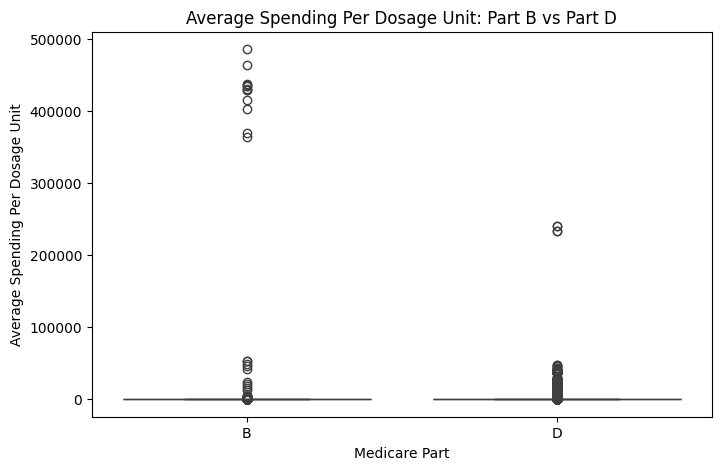

In [150]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=partBAndPartD_avgSpnd_perdsg,
    x='Part',
    y='Avg_Spend_Per_Unit'
)

plt.title("Average Spending Per Dosage Unit: Part B vs Part D")
plt.ylabel("Average Spending Per Dosage Unit")
plt.xlabel("Medicare Part")


In [151]:

#Average Spending Per Claim Unit Part B

partB_avgspend_perCLM_cols = [
    'Avg_Spndng_Per_Clm_2019',
    'Avg_Spndng_Per_Clm_2020',
    'Avg_Spndng_Per_Clm_2021',
    'Avg_Spndng_Per_Clm_2022',
    'Avg_Spndng_Per_Clm_2023']


partB_long_avgspend_perCLM = Medicare_PartB_SpendingByDrug_df.melt(
    id_vars=['Gnrc_Name'],
    value_vars=partB_avgspend_perCLM_cols,
    var_name='Year',
    value_name='Avg_Spend_Per_Claim'
)

partB_long_avgspend_perCLM['Part'] = 'B'


partB_long_avgspend_perCLM

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Clm_2019,428.974359,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Clm_2019,2765.240524,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,2526.913574,B
3,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,NaN,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Clm_2019,57.077578,B
...,...,...,...,...
3665,Iohexol,Avg_Spndng_Per_Clm_2023,32.720825,B
3666,Iodixanol*,Avg_Spndng_Per_Clm_2023,6.915482,B
3667,Iodixanol*,Avg_Spndng_Per_Clm_2023,11.635802,B
3668,Buprenorphine,Avg_Spndng_Per_Clm_2023,1661.877785,B


In [152]:
partB_long_avgspend_perCLM.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Clm_2019,428.974359,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Clm_2019,2765.240524,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,2526.913574,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Clm_2019,57.077578,B
5,Flu Vacc TS2017-18(65yr Up)/PF*,Avg_Spndng_Per_Clm_2019,51.809803,B
...,...,...,...,...
3665,Iohexol,Avg_Spndng_Per_Clm_2023,32.720825,B
3666,Iodixanol*,Avg_Spndng_Per_Clm_2023,6.915482,B
3667,Iodixanol*,Avg_Spndng_Per_Clm_2023,11.635802,B
3668,Buprenorphine,Avg_Spndng_Per_Clm_2023,1661.877785,B


In [153]:
#Average Spending Per Claim Unit Part D

partD_avgspend_perCLM_cols = [
    'Avg_Spnd_Per_Clm_2019',
    'Avg_Spnd_Per_Clm_2020',
    'Avg_Spnd_Per_Clm_2021',
    'Avg_Spnd_Per_Clm_2022',
    'Avg_Spnd_Per_Clm_2023']


partD_long_avgspend_perCLM = Medicare_PartD_SpendingByDrug_df.melt(
    id_vars=['Gnrc_Name'],
    value_vars=partD_avgspend_perCLM_cols,
    var_name='Year',
    value_name='Avg_Spend_Per_Claim'
)

partD_long_avgspend_perCLM['Part'] = 'D'


partD_long_avgspend_perCLM

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,25.816335,D
1,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,25.816335,D
2,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,23.525919,D
3,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,23.525919,D
4,Abacavir Sulfate,Avg_Spnd_Per_Clm_2019,237.170200,D
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71541,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,341.309059,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,366.352034,D


In [154]:
partD_long_avgspend_perCLM.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,25.816335,D
1,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,25.816335,D
2,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,23.525919,D
3,"Pen Needle, Diabetic",Avg_Spnd_Per_Clm_2019,23.525919,D
4,Abacavir Sulfate,Avg_Spnd_Per_Clm_2019,237.170200,D
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71541,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,341.309059,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,366.352034,D


In [155]:
PartDandPartB_avgSpnd_PerCLM = pd.concat([partB_long_avgspend_perCLM,partD_long_avgspend_perCLM])
PartDandPartB_avgSpnd_PerCLM

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Clm_2019,428.974359,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Clm_2019,2765.240524,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,2526.913574,B
3,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,NaN,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Clm_2019,57.077578,B
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71541,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,341.309059,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,366.352034,D


In [156]:
PartDandPartB_avgSpnd_PerCLM.dropna()

,Gnrc_Name,Year,Avg_Spend_Per_Claim,Part
0,Hepatitis B Immune Globulin*,Avg_Spndng_Per_Clm_2019,428.974359,B
1,Rabies Immune Globulin/PF*,Avg_Spndng_Per_Clm_2019,2765.240524,B
2,Rabies Immune Globulin/PF,Avg_Spndng_Per_Clm_2019,2526.913574,B
4,Hepatitis A Virus Vaccine/PF*,Avg_Spndng_Per_Clm_2019,57.077578,B
5,Flu Vacc TS2017-18(65yr Up)/PF*,Avg_Spndng_Per_Clm_2019,51.809803,B
...,...,...,...,...
71540,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71541,Linezolid,Avg_Spnd_Per_Clm_2023,1669.528667,D
71542,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,341.309059,D
71543,Linezolid In Dextrose 5%,Avg_Spnd_Per_Clm_2023,366.352034,D


In [157]:
PartDandPartB_avgSpnd_PerCLM = PartDandPartB_avgSpnd_PerCLM.reset_index(drop=True)

Text(0.5, 0, 'Medicare Part')

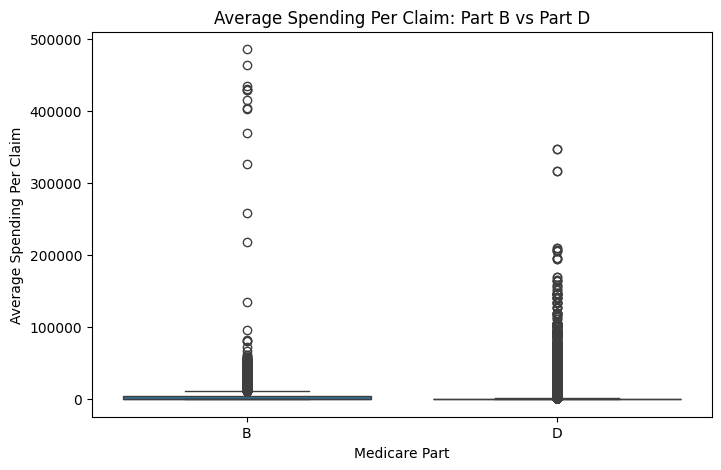

In [160]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=PartDandPartB_avgSpnd_PerCLM,
    x='Part',
    y='Avg_Spend_Per_Claim'
)

plt.title("Average Spending Per Claim: Part B vs Part D")
plt.ylabel("Average Spending Per Claim")
plt.xlabel("Medicare Part")

**Part B Discarded Drug Units Analysis**

In [189]:
filepath = 'Medicare_Part_B_Discarded_Drug_Units_2023.xlsx'
PartB_DiscardedDrgUnts_df = pd.read_excel(filepath)

In [190]:
PartB_DiscardedDrgUnts_df

,HCPCS_Cd,Brnd_Name,Gnrc_Name,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Alowd_Admnrd_Amt,Tot_Mdcr_Alowd_Dscrd_Amt,PCT_Admnrd_Units,PCT_Dscrd_Units
0,Overall,Overall,Overall,5.266303e+10,5.172795e+10,9.350775e+08,0.982244,0.017756
1,J9228,Yervoy,Ipilimumab,4.715190e+08,4.108384e+08,6.068063e+07,0.871308,0.128692
2,J0585,Botox*,Onabotulinumtoxina*,4.502990e+08,4.059647e+08,4.433431e+07,0.901545,0.098455
3,J2796,NPlate,Romiplostim,3.341990e+08,2.919351e+08,4.226387e+07,0.873537,0.126463
4,J9264,Abraxane*,Paclitaxel Protein-Bound*,2.953754e+08,2.536109e+08,4.176450e+07,0.858605,0.141395
...,...,...,...,...,...,...,...,...
819,Q4203,"Derma-gide, per square centimeter**",NaN,1.707814e+04,NaN,NaN,NaN,NaN
820,Q4226,"Myown skin, includes harvesting and preparatio...",NaN,1.476768e+06,NaN,NaN,NaN,NaN
821,Q4247,"Amniotext patch, per square centimeter**",NaN,3.002383e+06,NaN,NaN,NaN,NaN
822,Q4252,"Vendaje, per square centimeter**",NaN,5.851315e+04,NaN,NaN,NaN,NaN


In [191]:
#Dataset contains 638 unique HCPCS-coded drug products and eaach drug product has unique brand name; thus 638 unique brand names
#each HCPCS coded corresponds to one brand name
PartB_DiscardedDrgUnts_df.dropna()

,HCPCS_Cd,Brnd_Name,Gnrc_Name,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Alowd_Admnrd_Amt,Tot_Mdcr_Alowd_Dscrd_Amt,PCT_Admnrd_Units,PCT_Dscrd_Units
0,Overall,Overall,Overall,5.266303e+10,5.172795e+10,9.350775e+08,0.982244,0.017756
1,J9228,Yervoy,Ipilimumab,4.715190e+08,4.108384e+08,6.068063e+07,0.871308,0.128692
2,J0585,Botox*,Onabotulinumtoxina*,4.502990e+08,4.059647e+08,4.433431e+07,0.901545,0.098455
3,J2796,NPlate,Romiplostim,3.341990e+08,2.919351e+08,4.226387e+07,0.873537,0.126463
4,J9264,Abraxane*,Paclitaxel Protein-Bound*,2.953754e+08,2.536109e+08,4.176450e+07,0.858605,0.141395
...,...,...,...,...,...,...,...,...
672,Q4074,Ventavis,Iloprost Tromethamine,3.536416e+06,3.536416e+06,0.000000e+00,1.000000,0.000000
673,Q4081,Epogen (Q4081)*,Epoetin Alfa*,8.588270e+03,8.588270e+03,0.000000e+00,1.000000,0.000000
685,Q9960,Conray-43,Iothalamate Meglumine,8.232100e+02,8.232100e+02,0.000000e+00,1.000000,0.000000
686,Q9991,Sublocade (Q9991),Buprenorphine,1.095329e+06,1.095329e+06,0.000000e+00,1.000000,0.000000


Text(0.5, 1.0, 'Discarded Drug Units vs. Medicare Payment for Discarded Drug Units')

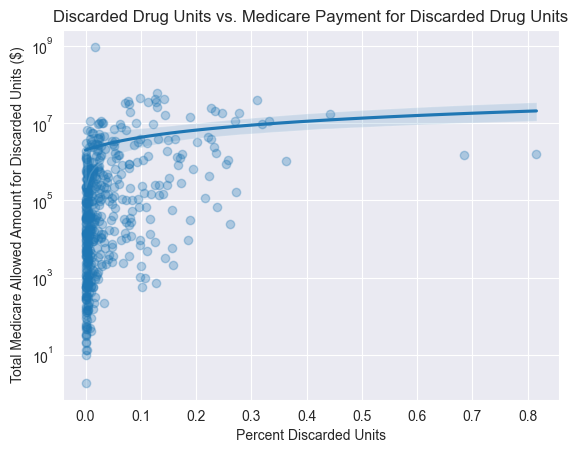

In [197]:
#creating a scatterplot visualization between Percent Total Discarded Units and Total Discarded Medciare Payment
#scatter plot with added a regression line:
sns.regplot(
    data=PartB_DiscardedDrgUnts_df,
    x='PCT_Dscrd_Units',
    y='Tot_Mdcr_Alowd_Dscrd_Amt',
    scatter_kws={'alpha':0.3}
)
plt.yscale('log')
plt.xlabel("Percent Discarded Units")
plt.ylabel("Total Medicare Allowed Amount for Discarded Units ($)")
plt.title("Discarded Drug Units vs. Medicare Payment for Discarded Drug Units")